# Market Structured Bars

## Overview

This notebook demonstrates the public functions in `market_structured_bars` using a compact synthetic trade stream.
- Problem: time bars can mix periods with very different trading activity.
- Approach: construct alternative bars from deterministic intraday trades and compare their sampling frequency.
- Define Synthetic Trades: It creates a deterministic trade stream with changing daily activity and price levels.
- Standard Bars: It compares the exponentially weighted daily frequencies of tick, volume, and dollar bars.
- Imbalance Bars: It constructs tick, volume, and dollar imbalance bars and compares their daily frequencies.
- Run Bars: It constructs tick, volume, and dollar run bars and compares their daily frequencies.
- CUSUM Event Filter: It identifies event timestamps from dollar-bar close changes and visualizes the sampled observations.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from src.data_preprocessing.market_structured_bars import (
    get_dollar_bars,
    get_dollar_imbalance_bars,
    get_dollar_run_bars,
    get_tick_bars,
    get_tick_imbalance_bars,
    get_tick_run_bars,
    get_volume_bars,
    get_volume_imbalance_bars,
    get_volume_run_bars,
    get_cusum_events,
)

## Define Synthetic Trades

This cell defines the reproducible intraday trade stream used by the examples below.
- `timestamp` is the execution timestamp of each trade.
- `symbol` identifies the traded instrument.
- `price` is the trade execution price.
- `size` is the executed quantity.
- The fixed random seed preserves the same price path and trade sizes across executions.
- Daily trade counts vary independently, while alternating directional regimes create observable imbalances and runs.
- The price follows one continuous path across trading days, and daily dollar value remains approximately constant.


In [3]:
rng = np.random.default_rng(42)
trading_days = pd.bdate_range("2024-01-02", periods=60, tz="UTC")
trades_per_day = rng.integers(80, 121, size=len(trading_days))
target_daily_dollar_value = 2_000_000.0

timestamp_parts = []
return_parts = []
size_parts = []
for day_number, (trading_day, num_trades) in enumerate(zip(trading_days, trades_per_day)):
    minutes_from_open = np.linspace(14 * 60 + 30, 20 * 60 + 30, num_trades, endpoint=False).astype(int)
    day_timestamps = trading_day + pd.to_timedelta(minutes_from_open, unit="m")
    regime_sign = 1.0 if day_number % 2 == 0 else -1.0
    run_signs = np.where(rng.random(num_trades) < 0.70, regime_sign, -regime_sign)
    day_returns = run_signs * rng.uniform(0.0002, 0.0010, num_trades)
    raw_sizes = rng.lognormal(3.7, 0.45, num_trades)
    raw_sizes *= np.where(run_signs == regime_sign, 1.5, 0.75)

    timestamp_parts.append(day_timestamps)
    return_parts.append(day_returns)
    size_parts.append(raw_sizes)

timestamps = np.concatenate(timestamp_parts)
prices = 100.0 * np.exp(np.cumsum(np.concatenate(return_parts)))
raw_sizes = np.concatenate(size_parts)
day_labels = np.repeat(np.arange(len(trading_days)), trades_per_day)
daily_raw_dollar_value = pd.Series(prices * raw_sizes).groupby(day_labels).transform("sum").to_numpy()
sizes = np.maximum(1, np.rint(raw_sizes * target_daily_dollar_value / daily_raw_dollar_value)).astype(int)
trades = pd.DataFrame({"timestamp": timestamps, "symbol": "AAPL", "price": prices, "size": sizes})

print("source: synthetic intraday trade stream")
print(f"num_trades: {len(trades):,}")
trades.head()

source: synthetic intraday trade stream
num_trades: 6,062


,timestamp,symbol,price,size
0,2024-01-02 14:30:00+00:00,AAPL,99.933684,233
1,2024-01-02 14:34:00+00:00,AAPL,99.899571,73
2,2024-01-02 14:38:00+00:00,AAPL,99.988050,161
3,2024-01-02 14:43:00+00:00,AAPL,100.068755,322
4,2024-01-02 14:47:00+00:00,AAPL,100.146395,202


## Standard Bars

This cell constructs standard bars from the synthetic trade stream.
- `target_bars_per_day` sets comparable standard-bar thresholds from the observed trade count, volume, and dollar value.
- `Tick Bar` reports the number of bars sampled after a fixed number of trades.
- `Volume Bar` reports the number of bars sampled after a fixed traded quantity.
- `Dollar Bar` reports the number of bars sampled after a fixed traded dollar value.
- `standard_bar_results` retains both the sampled trade rows and their aggregated OHLCV values.
- The daily-frequency plot compares the stability of tick, volume, and dollar bar counts.


In [4]:
price = trades["price"].astype(float)
size = trades["size"].astype(float)
notional = price * size

target_bars_per_day = 6
num_trading_days = trades["timestamp"].dt.normalize().nunique()
target_num_bars = max(1, num_trading_days * target_bars_per_day)
standard_thresholds = {
    "tick": max(1, len(trades) // target_num_bars),
    "volume": float(size.sum() / target_num_bars),
    "dollar": float(notional.sum() / target_num_bars),
}

standard_bar_results = {
    "Tick Bar": get_tick_bars(trades, threshold=standard_thresholds["tick"]),
    "Volume Bar": get_volume_bars(trades, threshold=standard_thresholds["volume"]),
    "Dollar Bar": get_dollar_bars(trades, threshold=standard_thresholds["dollar"]),
}

pd.Series({name: len(result.ohlcv) for name, result in standard_bar_results.items()}, name="num_bars").to_frame()


,num_bars
Tick Bar,378
Volume Bar,346
Dollar Bar,347


This cell plots the exponentially weighted daily bar frequencies.
- The `end` index identifies the trading day represented by each row.
- `Tick Bar` is the daily frequency of fixed trade-count sampling.
- `Volume Bar` is the daily frequency of fixed share-volume sampling.
- `Dollar Bar` is the daily frequency of fixed dollar-value sampling.
- Dollar bars are expected to vary less with price-level changes than tick or volume bars.


,Tick Bar,Volume Bar,Dollar Bar
end,,,
2024-01-02 00:00:00+00:00,5,5,5
2024-01-03 00:00:00+00:00,7,6,6
2024-01-04 00:00:00+00:00,6,6,6
2024-01-05 00:00:00+00:00,6,5,6
2024-01-08 00:00:00+00:00,6,6,6


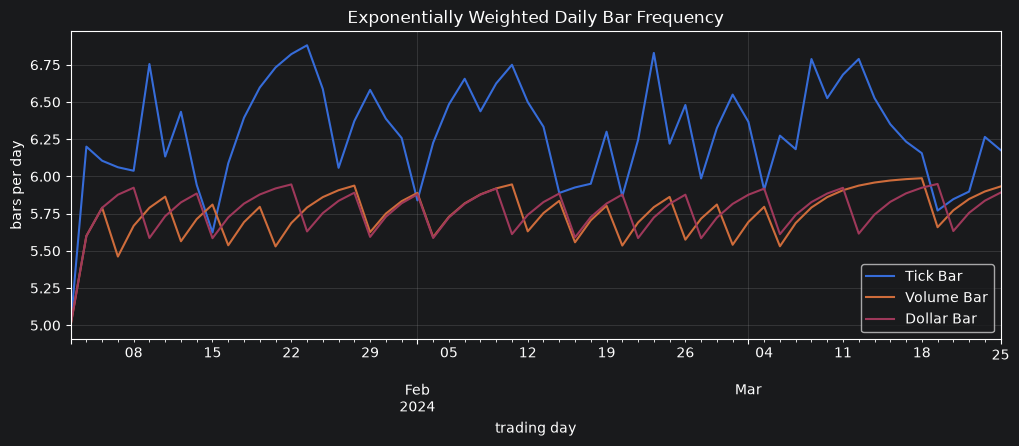

In [5]:
daily_bar_counts = pd.DataFrame(
    {
        name: result.ohlcv.groupby(result.ohlcv.index.normalize()).size()
        for name, result in {
            "Tick Bar": standard_bar_results["Tick Bar"],
            "Volume Bar": standard_bar_results["Volume Bar"],
            "Dollar Bar": standard_bar_results["Dollar Bar"],
        }.items()
    }
)

ax = daily_bar_counts.ewm(span=5, min_periods=1).mean().plot(figsize=(12, 4), lw=1.5)
ax.set_title("Exponentially Weighted Daily Bar Frequency")
ax.set_xlabel("trading day")
ax.set_ylabel("bars per day")
ax.grid(alpha=0.25)

daily_bar_counts.head()

## Imbalance Bars

This cell constructs imbalance bars from the synthetic trade stream.
- `expected_num_ticks_init` sets the initial expected number of trades per imbalance bar.
- `expected_window` sets the window used to update the expected bar conditions.
- `Tick Imbalance Bar` reports the number of bars sampled from unexpected signed tick imbalance.
- `Volume Imbalance Bar` reports the number of bars sampled from unexpected signed volume imbalance.
- `Dollar Imbalance Bar` reports the number of bars sampled from unexpected signed dollar imbalance.
- `imbalance_bar_results` retains the sampled trade rows and aggregated OHLCV values for each method.


In [6]:
imbalance_bar_results = {
    "Tick Imbalance Bar": get_tick_imbalance_bars(trades, expected_num_ticks_init=20, expected_window=20),
    "Volume Imbalance Bar": get_volume_imbalance_bars(trades, expected_num_ticks_init=20, expected_window=20),
    "Dollar Imbalance Bar": get_dollar_imbalance_bars(trades, expected_num_ticks_init=20, expected_window=20),
}

pd.Series(
    {name: len(result.ohlcv) for name, result in imbalance_bar_results.items()},
    name="num_bars",
).to_frame()

,num_bars
Tick Imbalance Bar,997
Volume Imbalance Bar,970
Dollar Imbalance Bar,935


This cell plots the exponentially weighted daily imbalance-bar frequencies.
- The `end` index identifies the trading day represented by each row.
- `Tick Imbalance Bar` is the daily frequency of signed tick-imbalance sampling.
- `Volume Imbalance Bar` is the daily frequency of signed volume-imbalance sampling.
- `Dollar Imbalance Bar` is the daily frequency of signed dollar-imbalance sampling.
- Each series contains one finite frequency for every trading day.


,Tick Imbalance Bar,Volume Imbalance Bar,Dollar Imbalance Bar
end,,,
2024-01-02 00:00:00+00:00,4,4,4
2024-01-03 00:00:00+00:00,3,3,3
2024-01-04 00:00:00+00:00,4,4,4
2024-01-05 00:00:00+00:00,13,11,11
2024-01-08 00:00:00+00:00,15,15,15


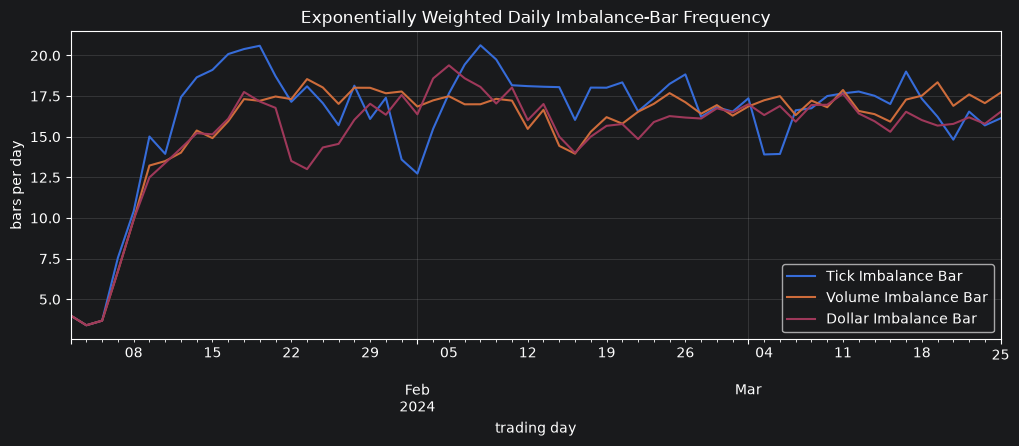

In [7]:
imbalance_daily_bar_counts = pd.DataFrame(
    {
        name: result.ohlcv.groupby(result.ohlcv.index.normalize()).size()
        for name, result in imbalance_bar_results.items()
    }
).reindex(trading_days).fillna(0)
imbalance_daily_bar_counts.index.name = "end"

ax = imbalance_daily_bar_counts.ewm(span=5, min_periods=1).mean().plot(figsize=(12, 4), lw=1.5)
ax.set_title("Exponentially Weighted Daily Imbalance-Bar Frequency")
ax.set_xlabel("trading day")
ax.set_ylabel("bars per day")
ax.grid(alpha=0.25)

imbalance_daily_bar_counts.head()

## Run Bars

This cell constructs run bars from the synthetic trade stream.
- `expected_num_ticks_init` sets the initial expected number of trades per run bar.
- `expected_window` sets the window used to update the expected bar conditions.
- `Tick Run Bar` reports the number of bars sampled from unexpected directional tick runs.
- `Volume Run Bar` reports the number of bars sampled from unexpected directional volume runs.
- `Dollar Run Bar` reports the number of bars sampled from unexpected directional dollar runs.
- `run_bar_results` retains the sampled trade rows and aggregated OHLCV values for each method.


In [8]:
run_bar_results = {
    "Tick Run Bar": get_tick_run_bars(trades, expected_num_ticks_init=20, expected_window=20),
    "Volume Run Bar": get_volume_run_bars(trades, expected_num_ticks_init=20, expected_window=20),
    "Dollar Run Bar": get_dollar_run_bars(trades, expected_num_ticks_init=20, expected_window=20),
}

pd.Series(
    {name: len(result.ohlcv) for name, result in run_bar_results.items()},
    name="num_bars",
).to_frame()

,num_bars
Tick Run Bar,685
Volume Run Bar,755
Dollar Run Bar,760


This cell plots the exponentially weighted daily run-bar frequencies.
- The `end` index identifies the trading day represented by each row.
- `Tick Run Bar` is the daily frequency of directional tick-run sampling.
- `Volume Run Bar` is the daily frequency of directional volume-run sampling.
- `Dollar Run Bar` is the daily frequency of directional dollar-run sampling.
- Each series contains one finite frequency for every trading day.


,Tick Run Bar,Volume Run Bar,Dollar Run Bar
end,,,
2024-01-02 00:00:00+00:00,4,4,4
2024-01-03 00:00:00+00:00,5,4,4
2024-01-04 00:00:00+00:00,5,4,4
2024-01-05 00:00:00+00:00,6,5,6
2024-01-08 00:00:00+00:00,7,7,7


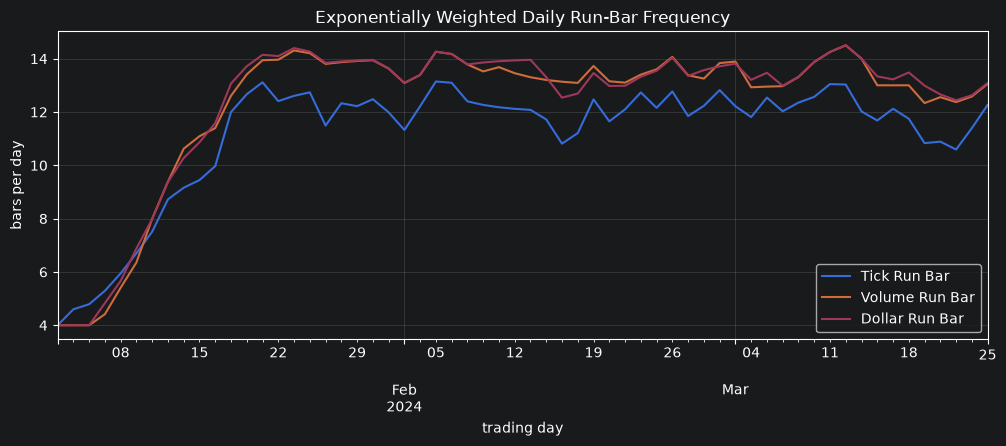

In [9]:
run_daily_bar_counts = pd.DataFrame(
    {
        name: result.ohlcv.groupby(result.ohlcv.index.normalize()).size()
        for name, result in run_bar_results.items()
    }
).reindex(trading_days).fillna(0)
run_daily_bar_counts.index.name = "end"

ax = run_daily_bar_counts.ewm(span=5, min_periods=1).mean().plot(figsize=(12, 4), lw=1.5)
ax.set_title("Exponentially Weighted Daily Run-Bar Frequency")
ax.set_xlabel("trading day")
ax.set_ylabel("bars per day")
ax.grid(alpha=0.25)

run_daily_bar_counts.head()

## CUSUM Event Filter

This cell applies `get_cusum_events` to the dollar-bar close series and visualizes the sampled observations.
- `dollar_close` is the price series sampled into dollar bars.
- `cusum_threshold` is three times the median absolute close-to-close change.
- `cusum_events` contains timestamps where the cumulative positive or negative price change crosses the threshold.
- `cusum_time` numbers the dollar-bar observations on a continuous horizontal axis.
- `event_positions` contains the observation numbers selected by the filter.
- The price line provides the complete dollar-bar path, while the markers identify observations selected by the CUSUM filter.


cusum_threshold: 1.2122
num_events: 72


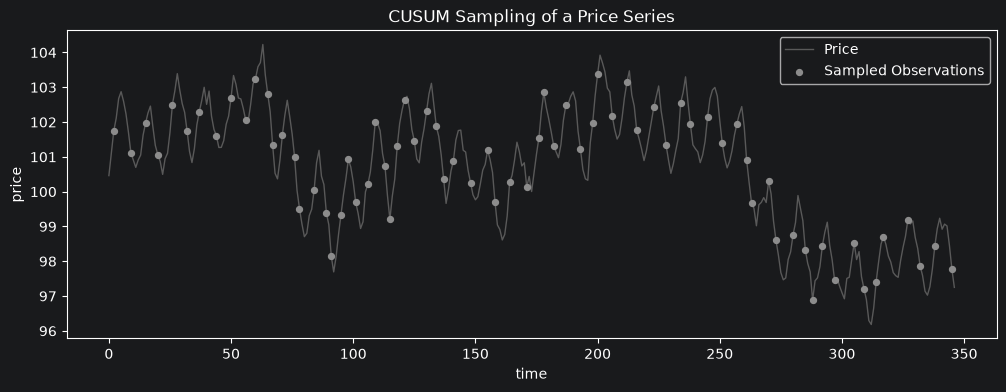

DatetimeIndex(['2024-01-02 17:53:00+00:00', '2024-01-03 18:46:00+00:00',
               '2024-01-04 18:58:00+00:00', '2024-01-05 18:16:00+00:00',
               '2024-01-08 18:12:00+00:00', '2024-01-09 18:24:00+00:00',
               '2024-01-10 17:32:00+00:00', '2024-01-11 18:46:00+00:00',
               '2024-01-12 19:16:00+00:00', '2024-01-15 19:20:00+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

In [10]:
dollar_close = standard_bar_results["Dollar Bar"].ohlcv["close"]
cusum_threshold = float(dollar_close.diff().abs().median() * 3)
cusum_events = get_cusum_events(dollar_close, threshold=cusum_threshold)
cusum_time = np.arange(len(dollar_close))
event_positions = dollar_close.index.get_indexer(cusum_events)

print(f"cusum_threshold: {cusum_threshold:.4f}")
print(f"num_events: {len(cusum_events)}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cusum_time, dollar_close, color="0.35", lw=1.0, label="Price")
ax.scatter(
    event_positions,
    dollar_close.loc[cusum_events],
    color="0.55",
    s=18,
    zorder=3,
    label="Sampled Observations",
)
ax.set_title("CUSUM Sampling of a Price Series")
ax.set_xlabel("time")
ax.set_ylabel("price")
ax.legend()
plt.show()

cusum_events[:10]